# Lab 02 — Chương 2: Visual models & encoding (Solution)

**Mục tiêu:** áp dụng Stevens (N/O/I/R) để chọn biểu đồ + encoding đúng.

**Đọc:** `related/english/chapter2.tex`


## Setup + load data (Gapminder)

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path("..").resolve().parent  # từ solutions/lab02... về repo root
df = pd.read_csv(root / "data" / "gapminder.csv")
df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


## Task — tạo một bảng (nominal, ordinal, ratio/interval, temporal)

Ta tạo bảng nhỏ từ Gapminder:
- **nominal**: `continent`
- **temporal**: `year`
- **ratio**: `gdpPercap`, `lifeExp` (xấp xỉ interval)
- **ordinal (tạo mới)**: nhóm `gdpPercap` theo quantile → `gdp_bin` (Low/Med/High)


In [2]:
# Chuẩn bị bảng cho 1 năm để minh họa rõ
year = 2007
d = df[df["year"] == year].copy()

# Tạo ordinal bin (3 mức) từ ratio gdpPercap
d["gdp_bin"] = pd.qcut(d["gdpPercap"], q=3, labels=["Low", "Medium", "High"])

# Tổng hợp theo nominal + ordinal
agg = (
    d.groupby(["continent", "gdp_bin"], observed=True)
    .agg(mean_lifeExp=("lifeExp", "mean"), n=("country", "count"))
    .reset_index()
)
agg.head()

,continent,gdp_bin,mean_lifeExp,n
0,Africa,Low,52.406486,37
1,Africa,Medium,61.625455,11
2,Africa,High,58.248500,4
3,Americas,Low,60.916000,1
4,Americas,Medium,73.044647,17


## 1) Biểu đồ **sai encoding** (cố ý)

Ví dụ sai phổ biến: dùng **pie chart** để so sánh **mean_lifeExp** theo `continent`
(một đại lượng interval/ratio) — pie làm người xem so “góc/diện tích” kém chính xác,
và không phù hợp khi cần so sánh tương đối tinh.


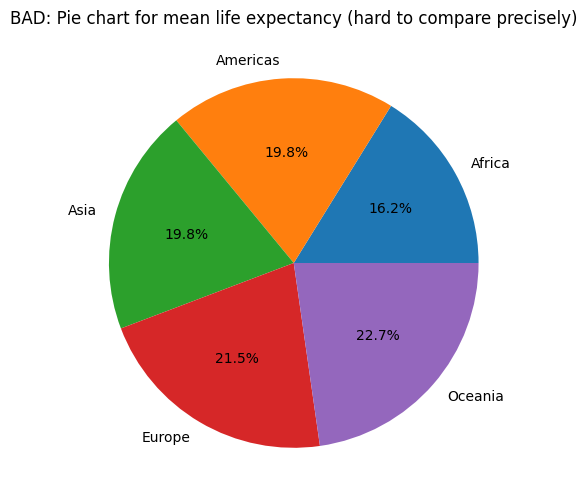

In [3]:
bad = agg.groupby("continent", as_index=False)["mean_lifeExp"].mean()

plt.figure(figsize=(6, 6))
plt.pie(bad["mean_lifeExp"], labels=bad["continent"], autopct="%.1f%%")
plt.title("BAD: Pie chart for mean life expectancy (hard to compare precisely)")
plt.show()

## 2) Phiên bản **sửa** đúng nguyên tắc

Chọn **bar chart** (position/length) giúp so sánh chính xác hơn.


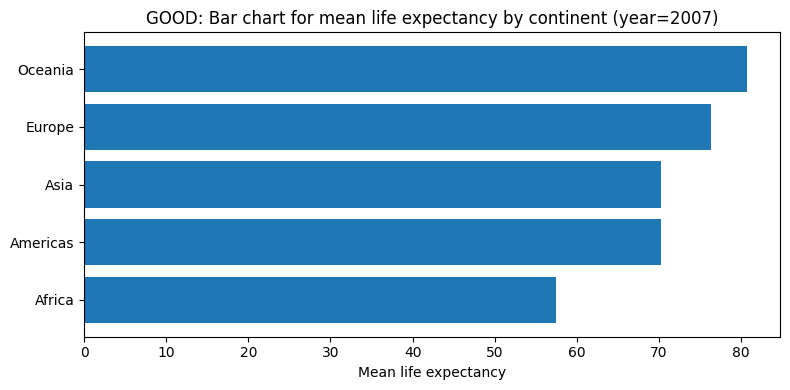

In [4]:
good = bad.sort_values("mean_lifeExp", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(good["continent"], good["mean_lifeExp"])
plt.xlabel("Mean life expectancy")
plt.title("GOOD: Bar chart for mean life expectancy by continent (year=2007)")
plt.tight_layout()
plt.show()

## Bonus: encoding cho temporal (time series)

Vì có `year` (temporal), line chart là phù hợp để xem trend.


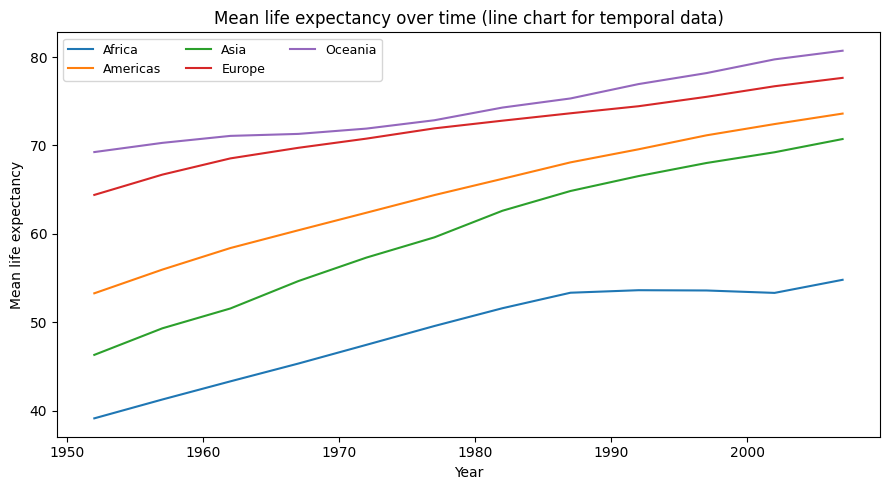

In [5]:
ts = (
    df.groupby(["year", "continent"], as_index=False)
    .agg(mean_lifeExp=("lifeExp", "mean"))
)

plt.figure(figsize=(9, 5))
for cont, g in ts.groupby("continent"):
    plt.plot(g["year"], g["mean_lifeExp"], label=cont)
plt.title("Mean life expectancy over time (line chart for temporal data)")
plt.xlabel("Year")
plt.ylabel("Mean life expectancy")
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

## Reflection (mẫu)

- **Visual model:** temporal → line chart; comparison between categories → bar chart.
- **Marks & channels:** bar (length/position), line (position), color chỉ dùng để phân biệt nhóm (continent).
- **Vì sao pie sai:** so sánh diện tích/góc kém chính xác, không hỗ trợ so sánh fine-grained.

**Họ tên / MSSV:** (điền khi chấm)
